In [49]:
import sys

sys.path.append("..")

import matplotlib.pyplot as plt
import numpy as np
import random
from pulp import *

In [50]:
from candidate.candidate import Candidate
from voter.voter import Voter
from election.election import Election
from election.result import ElectionResult
from analysis.analyzer import ResultsAnalyzer

from strategy.strategy import VotingStrategy
from strategy.plurality import PluralityStrategy
from strategy.borda import BordaCountStrategy
from strategy.veto import VetoStrategy

from visualization.util import (
    plot,
    plot_results,
    random_2d_points,
    random_2d_point,
    plot_winner_distance_histogram,
    plot_lp_result,
)

from calculation.calculation import find_farthest_pair, find_farthest_triple

from lp.lp import MarginalLpModel, PermutationLpModel

In [51]:
N_VOTERS = 1000
N_CANDIDATES = 3

In [52]:
# # winners = {
# #     "plurality": idxs[0],
# #     "borda": idxs[1]
# # }

# for _ in range(100):
#     candidates = [Candidate(id=id, position=random_2d_point()) for id in range(N_CANDIDATES)]
#     idxs = find_farthest_triple([candidate.position for candidate in candidates])
#     winners = {
#         "plurality": random.randint(0, len(candidates) - 1),
#         "borda": random.randint(0, len(candidates) - 1),
#         "veto": random.randint(0, len(candidates) - 1)
#     }

#     model = PermutationLpModel(
#         candidates=candidates,
#         n_voters = N_VOTERS,
#         winners=winners
#     )

#     if model.solve() == 'Optimal': break

# model.solve()

In [53]:
candidates = [
    Candidate(id=id, position=random_2d_point()) for id in range(N_CANDIDATES)
]
idxs = find_farthest_triple([candidate.position for candidate in candidates])

winners = {
    "plurality": random.randint(0, len(candidates) - 1),
    "borda": random.randint(0, len(candidates) - 1),
    "veto": random.randint(0, len(candidates) - 1),
}

model = PermutationLpModel(candidates=candidates, n_voters=N_VOTERS, winners=winners)
model.solve()

'Optimal'

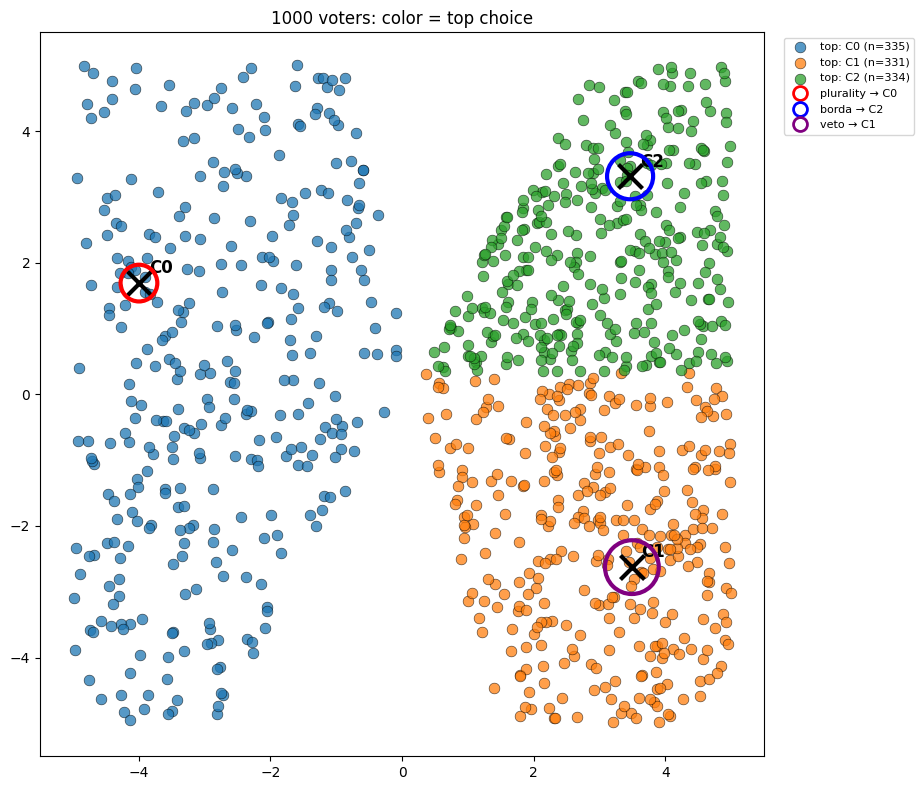

In [54]:
plot_lp_result(candidates, model.generate_voter_positions(), winners)